# Custom Model — Deep Light-Regularized CNN

Based on Model B, increasing network depth improved feature extraction and classification accuracy. However, Model B did not show substantial overfitting, while the strong combination of regularization techniques used in Model C produced unstable validation performance.

Therefore, the custom model increases the network depth to four convolutional blocks while applying lighter regularization. Data augmentation and a dropout rate of 0.2 are used, while batch normalization is removed. The objective is to evaluate whether increased capacity with moderate regularization improves classification performance and maintains generalization.

In [1]:
from pathlib import Path
import sys
import json
import time
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Asus\Desktop\AID-Scene_Classification


In [2]:
import json
import time
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from project_utils import (
    SEED,
    EPOCHS,
    TARGET_CLASSES,
    RESULTS_DIR,
    FIGURES_DIR,
    ARTIFACTS_DIR,
    set_seed,
    load_datasets,
    build_cnn,
)

In [3]:
set_seed()

train_ds, val_ds, test_ds = load_datasets()

for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 160, 160, 3)
Labels shape: (32,)


In [4]:
# Custom model: deeper CNN with light regularization
custom_model_config = {
    "name": "custom_deep_light_regularized",
    "filters": [32, 64, 128, 256],
    "kernel_size": 3,
    "augmentation": True,
    "batch_norm": False,
    "dense_units": 128,
    "dropout": 0.2,
}

In [5]:
tf.keras.backend.clear_session()
set_seed()

custom_model = build_cnn(
    num_classes=len(TARGET_CLASSES),
    config=custom_model_config,
)

custom_model.summary()

custom_model_params = (custom_model.count_params())

print(
    f"Total parameters: "
    f"{custom_model_params:,}"
)

Model: "custom_deep_light_regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,602 (1.61 MB)

 Trainable params: 422,602 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 422,602


In [6]:
#model compile
custom_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [7]:
start_time_custom = time.time()

history_custom = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

train_time_sec_custom = (
    time.time() - start_time_custom
)

print(
    f"\nTraining time: "
    f"{train_time_sec_custom:.1f} "
    f"sec for {EPOCHS} epochs"
)

Epoch 1/15


c:\Users\Asus\Desktop\AID-Scene_Classification\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


77/77 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.2524 - loss: 2.0201 - val_accuracy: 0.4318 - val_loss: 1.5882
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.4472 - loss: 1.4850 - val_accuracy: 0.4924 - val_loss: 1.3009
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.5203 - loss: 1.2866 - val_accuracy: 0.5777 - val_loss: 1.1908
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.5657 - loss: 1.1684 - val_accuracy: 0.6155 - val_loss: 1.0748
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.5998 - loss: 1.1018 - val_accuracy: 0.6515 - val_loss: 0.9257
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.6652 - loss: 0.9508 - val_accuracy: 0.6837 - val_loss: 0.8370
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.6636 - loss: 0.9354 - val_accuracy: 0.7045 - val_loss: 0.8331
Epoch 8/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.7029 - loss: 0.8327 - val_accuracy: 0.5871 - val_loss: 1.04

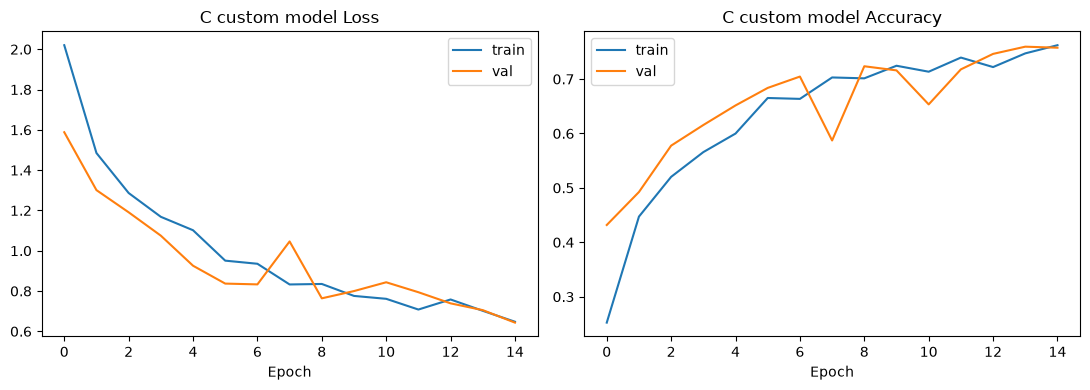

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_custom.history["loss"], label="train")
axes[0].plot(history_custom.history["val_loss"], label="val")
axes[0].set_title("C custom model Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_custom.history["accuracy"], label="train")
axes[1].plot(history_custom.history["val_accuracy"], label="val")
axes[1].set_title("C custom model Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "custom_deep_light_regularized_curves.png"), dpi=120)
plt.show()

C custom model test accuracy: 0.7576 | test loss: 0.6720


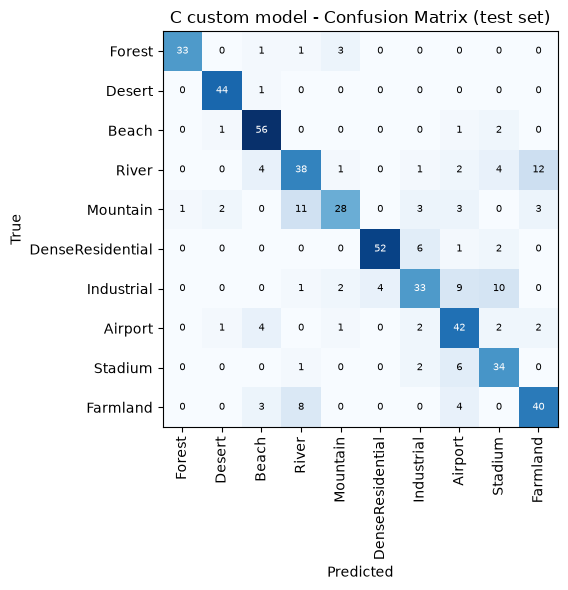

                  precision    recall  f1-score   support

          Forest       0.97      0.87      0.92        38
          Desert       0.92      0.98      0.95        45
           Beach       0.81      0.93      0.87        60
           River       0.63      0.61      0.62        62
        Mountain       0.80      0.55      0.65        51
DenseResidential       0.93      0.85      0.89        61
      Industrial       0.70      0.56      0.62        59
         Airport       0.62      0.78      0.69        54
         Stadium       0.63      0.79      0.70        43
        Farmland       0.70      0.73      0.71        55

        accuracy                           0.76       528
       macro avg       0.77      0.76      0.76       528
    weighted avg       0.77      0.76      0.76       528



In [9]:
test_loss_c , test_acc_c = custom_model.evaluate(test_ds, verbose=0)
print(f"C custom model test accuracy: {test_acc_c:.4f} | test loss: {test_loss_c:.4f}")

y_true_c, y_pred_c = [], []
for imgs, labels in test_ds:
    probs = custom_model.predict(imgs, verbose=0)
    y_true_c.extend(labels.numpy().tolist())
    y_pred_c.extend(np.argmax(probs, axis=1).tolist())

cm = confusion_matrix(y_true_c, y_pred_c)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(TARGET_CLASSES))); ax.set_xticklabels(TARGET_CLASSES, rotation=90)
ax.set_yticks(range(len(TARGET_CLASSES))); ax.set_yticklabels(TARGET_CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("C custom model - Confusion Matrix (test set)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "custom_deep_light_regularized_confusion_matrix.png"), dpi=120)
plt.show()

print(classification_report(y_true_c, y_pred_c, target_names=TARGET_CLASSES))

In [10]:
custom_model.save(
    os.path.join(
        ARTIFACTS_DIR,
        "custom_deep_light_regularized.keras",
    )
)

history_out = {
    "model": "custom_deep_light_regularized",
    "config": custom_model_config,
    "epochs": EPOCHS,
    "train_time_sec": float(
        train_time_sec_custom
    ),
    "n_params": int(
        custom_model_params
    ),
    "test_accuracy": float(
        test_acc_c
    ),
    "test_loss": float(
        test_loss_c
    ),
    "history": {
        k: [float(v) for v in vals]
        for k, vals
        in history_custom.history.items()
    },
}

with open(
    os.path.join(
        RESULTS_DIR,
        "custom_deep_light_regularized_history.json",
    ),
    "w",
) as f:
    json.dump(
        history_out,
        f,
        indent=2,
    )

print(
    "Saved model to",
    os.path.join(
        ARTIFACTS_DIR,
        "custom_deep_light_regularized.keras",
    ),
)

print(
    "Saved training history to",
    os.path.join(
        RESULTS_DIR,
        "custom_deep_light_regularized_history.json",
    ),
)

Saved model to C:\Users\Asus\Desktop\AID-Scene_Classification\artifacts\custom_deep_light_regularized.keras
Saved training history to C:\Users\Asus\Desktop\AID-Scene_Classification\results\custom_deep_light_regularized_history.json


## Findings

The Custom Deep Light-Regularized CNN increased the network depth to four convolutional blocks with progressive filters of 32, 64, 128, and 256. Since Model B did not show substantial overfitting, the custom model used lighter regularization through data augmentation and a dropout rate of 0.2, while batch normalization was removed.

The custom architecture achieved a test accuracy of 75.76%, a test loss of 0.6720, and a macro F1-score of 0.76. This improved test accuracy from 68.37% in Model B to 75.76%. The final training and validation accuracies were 76.22% and 75.76%, respectively, indicating stable generalization with no significant overfitting.

The model performed particularly well on Desert, Forest, DenseResidential, and Beach, with F1-scores of 0.95, 0.92, 0.89, and 0.87, respectively. Mountain also improved substantially compared with Model B, although River and Industrial remained the most difficult classes.

Overall, increasing network depth while applying lighter regularization significantly improved classification performance. The custom model achieved the highest test accuracy under the original 15-epoch training constraint, demonstrating that increased feature capacity with moderate regularization was effective for the selected aerial scene dataset.